<a href="https://colab.research.google.com/github/TerradasExatas/Metodos_Matematicos/blob/main/Modelagem_EDOxML_01dnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

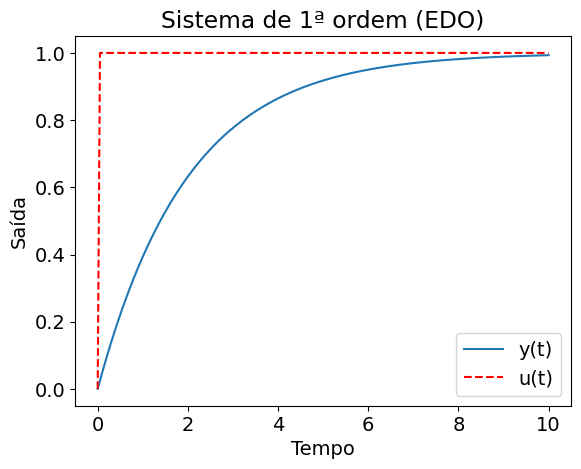

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
def sistema(y, t, tau):
    u = 1.0
    dydt = (-y + u)/tau
    return dydt
tau = 2.0;y0 = 0
t = np.linspace(0, 10, 200)
y = odeint(sistema, y0, t, args=(tau,))
u = np.ones_like(t);u[0]=0
plt.figure()
plt.plot(t, y,label="y(t)")
plt.plot(t, u,'r--',label="u(t)")
plt.legend()
plt.xlabel("Tempo");plt.ylabel("Saída")
plt.title("Sistema de 1ª ordem (EDO)")
plt.rcParams.update({'font.size': 14})
plt.show()

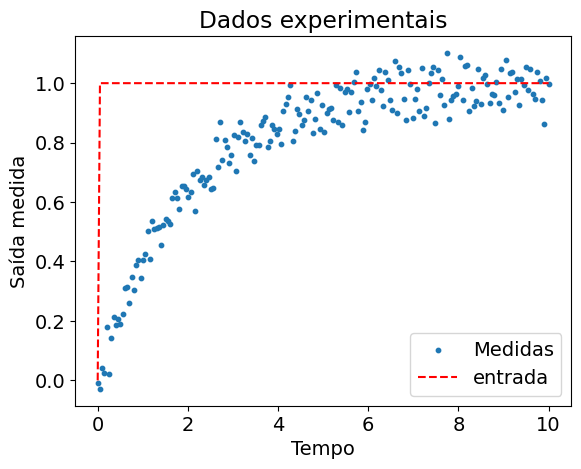

In [17]:
ruido = 0.05*np.random.randn(len(t))
y_medida = y.flatten() + ruido

plt.figure()
plt.scatter(t, y_medida, s=10,label="Medidas")
plt.plot(t, u,'r--',label="entrada")
plt.legend()
plt.xlabel("Tempo")
plt.ylabel("Saída medida")
plt.title("Dados experimentais")
plt.show()

tau estimado=  [2.00928326]


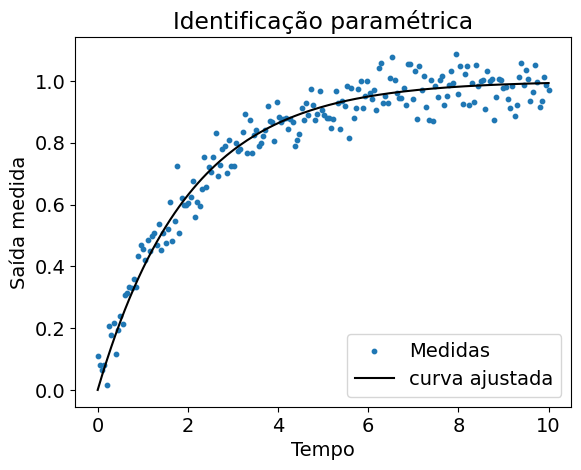

In [16]:
from scipy.optimize import curve_fit

def modelo(t, tau):
    return 1 - np.exp(-t/tau)

tau_est, _ = curve_fit(modelo, t, y_medida)
print('tau estimado= ',tau_est)
y_fit = modelo(t, tau_est)
plt.figure()
plt.scatter(t, y_medida,s=10, label="Medidas")
plt.plot(t, y_fit, label="curva ajustada", color="k")
plt.legend()
plt.xlabel("Tempo");plt.ylabel("Saída")
plt.title("Identificação paramétrica")
plt.show()

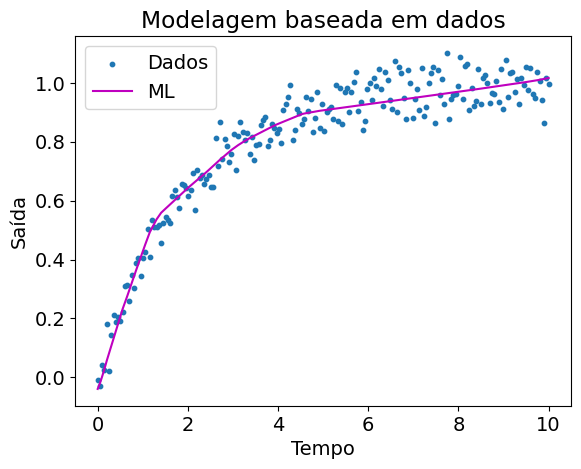

In [64]:
from sklearn.neural_network import MLPRegressor

X = t.reshape(-1,1)
mlp = MLPRegressor(
    hidden_layer_sizes=(40,200,20), max_iter=100000)
mlp.fit(X, y_medida)

y_pred = mlp.predict(X)

plt.figure()
plt.scatter(t, y_medida,s=10, label="Dados")
plt.plot(t, y_pred, label="ML", color="m")
plt.legend()
plt.xlabel("Tempo");plt.ylabel("Saída")
plt.title("Modelagem baseada em dados")
plt.show()

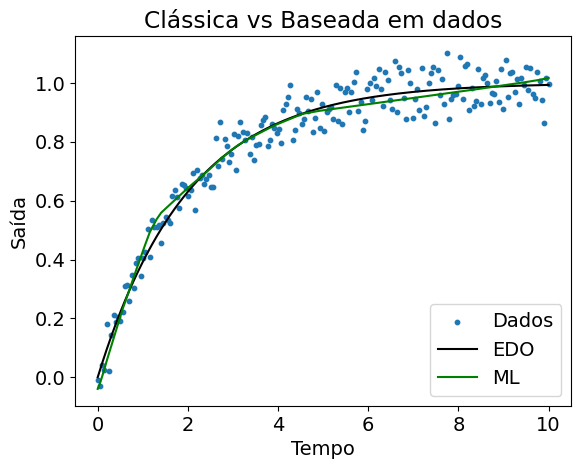

In [73]:
plt.figure()
plt.scatter(t, y_medida,s=10, label="Dados")
plt.plot(t, y_fit, label="EDO", color="k")
plt.plot(t, y_pred, label="ML", color="g")
plt.xlabel("Tempo");plt.ylabel("Saída")
plt.title("Clássica vs Baseada em dados")
plt.legend(loc='lower right')
plt.show()


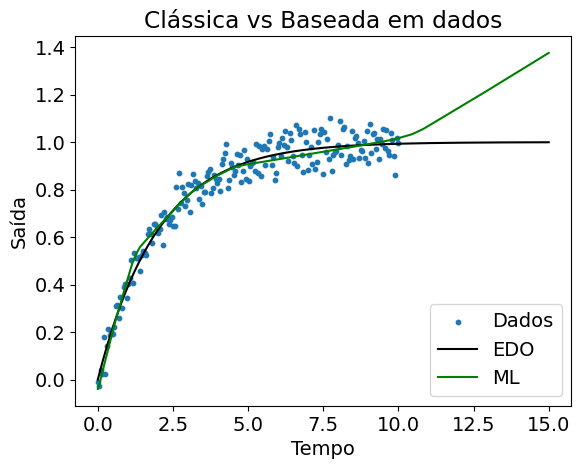

In [74]:

t_new = np.linspace(0, 15, 300)

X = t_new.reshape(-1,1)
y_pred_new = mlp.predict(X)
y_fit_new = modelo(t_new, tau_est)

plt.figure()
plt.scatter(t, y_medida,s=10, label="Dados")
plt.plot(t_new, y_fit_new, label="EDO", color="k")
plt.plot(t_new, y_pred_new, label="ML", color="g")
plt.xlabel("Tempo");plt.ylabel("Saída")
plt.title("Extrapolando os dados")
plt.legend(loc='lower right')
plt.show()